In [2]:
#import libaries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 

import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_selection import SelectKBest as skb
from sklearn.feature_selection import f_regression

from sklearn.model_selection import train_test_split as tts

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor

from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, r2_score

In [3]:
#import data
df = pd.read_csv('credit_risk_dataset.csv')

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Link to orginal data: https://www.kaggle.com/datasets/laotse/credit-risk-dataset/data 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
#summary statistics for numeric variables
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<p> Max for age is 144 <br>
Max employment length is 123 years </p>

Both of these are outliers. They will need to be removed. 

In [6]:
#check for null values
print("Null values:")
print(df.isnull().sum())

Null values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


For missing employment length will drop missing values (~3% of data)

For missing interest rate will find average for each type of loan and insert values rather than dropping

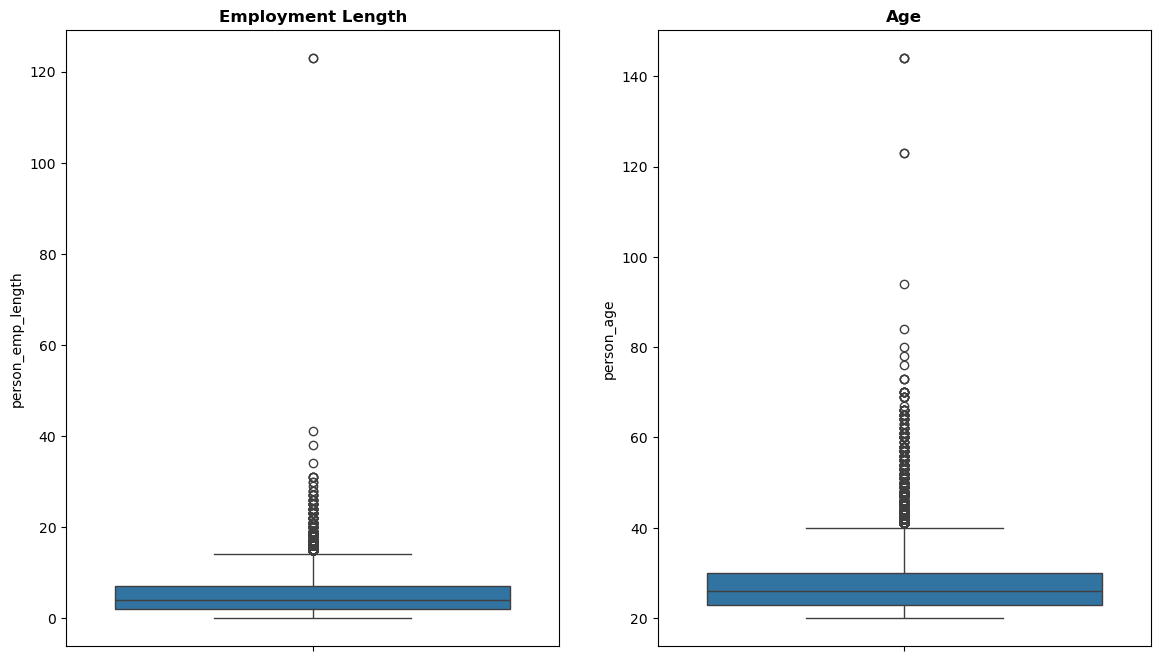

In [7]:
#check for outliers 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 8), sharex=False) 


sns.boxplot(df['person_emp_length'], ax=axes[0])
axes[0].set_title('Employment Length',fontsize = 12,weight = 'bold')

sns.boxplot(df['person_age'], ax=axes[1])
axes[1].set_title('Age',fontsize = 12,weight = 'bold')

plt.show()

Only outlier in employment lenght is 123 years, the other data makes sense. 

Any age over 100 is unlikely. The oldest person ever recorded was 122 years will drop any age greater than 100

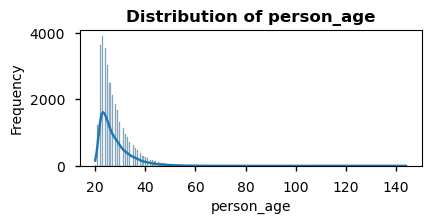

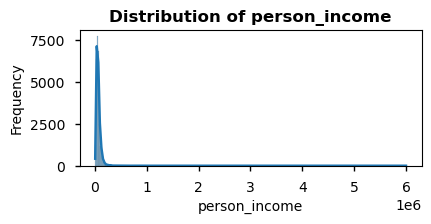

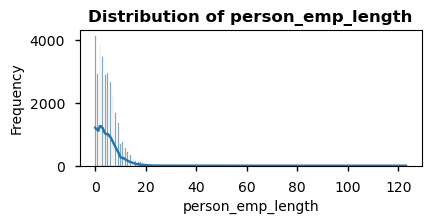

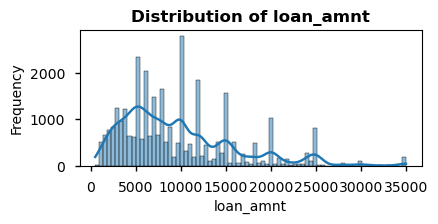

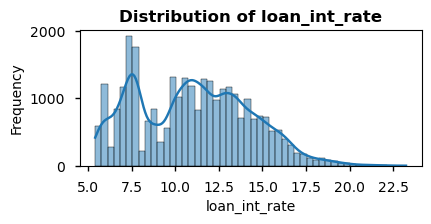

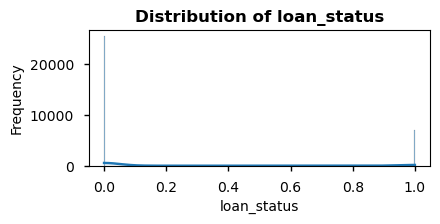

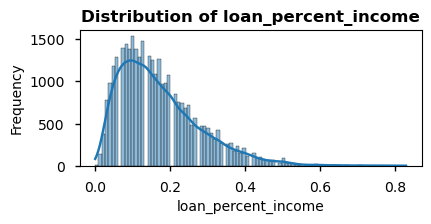

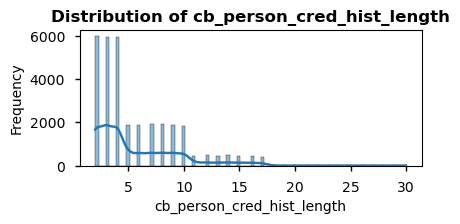

In [8]:
#frequency and distribution visualizations before cleaning
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col].dtype):
        plt.figure(figsize = (15,6))
        plt.style.use('seaborn-v0_8-notebook')
        plt.subplot(3,3,3)
        sns.histplot(df[col],kde = True)
        plt.ylabel('Frequency',fontsize = 10)
        plt.xlabel(col,fontsize = 10)
        plt.title(f'Distribution of {col}',fontsize = 12,weight = 'bold')
        plt.show()

In [9]:
#data distribution of categorical variables before cleaning
for col in df.columns:
    if df[col].dtype == 'O':
        print(df[col].value_counts())
        print('----------------------')

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64
----------------------
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
----------------------
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
----------------------
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64
----------------------


In [10]:
#clean data
#drop missing values in person_emp_length
df2 = df.copy()
df2 = df2.dropna(subset=['person_age'])
print("Number of null values:",df2['person_age'].isnull().sum())

# drop outliers in age and employment history
df2 = df2.loc[df2['person_age'] <100]
df2 = df2.loc[df2['person_emp_length'] <=100]

#check data is correct 
print("Max age:",max(df2['person_age']))
print("Max employment length:", max(df2['person_emp_length']))

Number of null values: 0
Max age: 94
Max employment length: 41.0


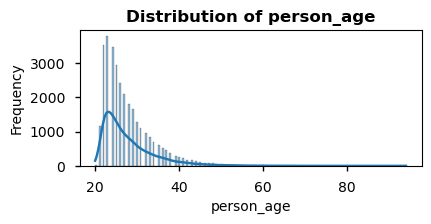

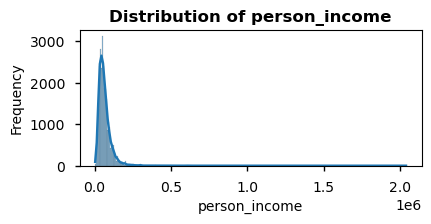

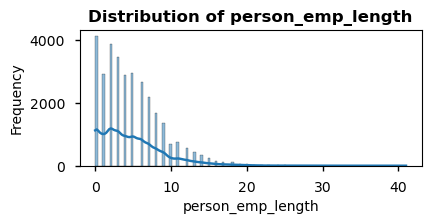

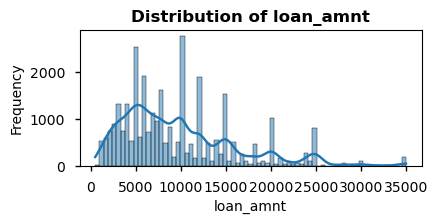

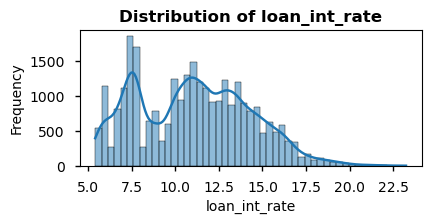

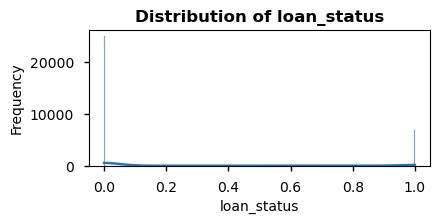

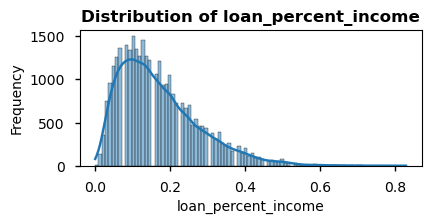

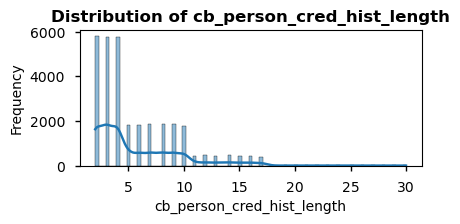

In [11]:
#frequency and distribution visualizations after cleaning
for col in df2.columns:
    if pd.api.types.is_numeric_dtype(df2[col].dtype):
        plt.figure(figsize = (15,6))
        plt.style.use('seaborn-v0_8-notebook')
        plt.subplot(3,3,3)
        sns.histplot(df2[col],kde = True)
        plt.ylabel('Frequency',fontsize = 10)
        plt.xlabel(col,fontsize = 10)
        plt.title(f'Distribution of {col}',fontsize = 12,weight = 'bold')
        plt.show()

In [12]:
#find average interest rate by loan intent 
loan_intent_avg = df2.groupby(['loan_intent'])[['loan_int_rate']].mean().reset_index()
loan_intent_avg

,loan_intent,loan_int_rate
0,DEBTCONSOLIDATION,11.022421
1,EDUCATION,10.982557
2,HOMEIMPROVEMENT,11.225819
3,MEDICAL,11.079414
4,PERSONAL,11.019530
5,VENTURE,10.979220


In [13]:
#replace null values in loan_int_rate with average value -- map average rates to intent
mapping = {
    'DEBTCONSOLIDATION': 11.02,
    'EDUCATION': 10.98,
    'HOMEIMPROVEMENT': 11.22,
    'MEDICAL':	11.08,
    'PERSONAL':	11.01,
	'VENTURE':	10.98
    
}

df2['loan_int_rate'] = df2['loan_int_rate'].fillna(df2['loan_intent'].map(mapping))

df2.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3
10,22,85000,RENT,6.0,VENTURE,B,35000,10.37,1,0.41,N,4


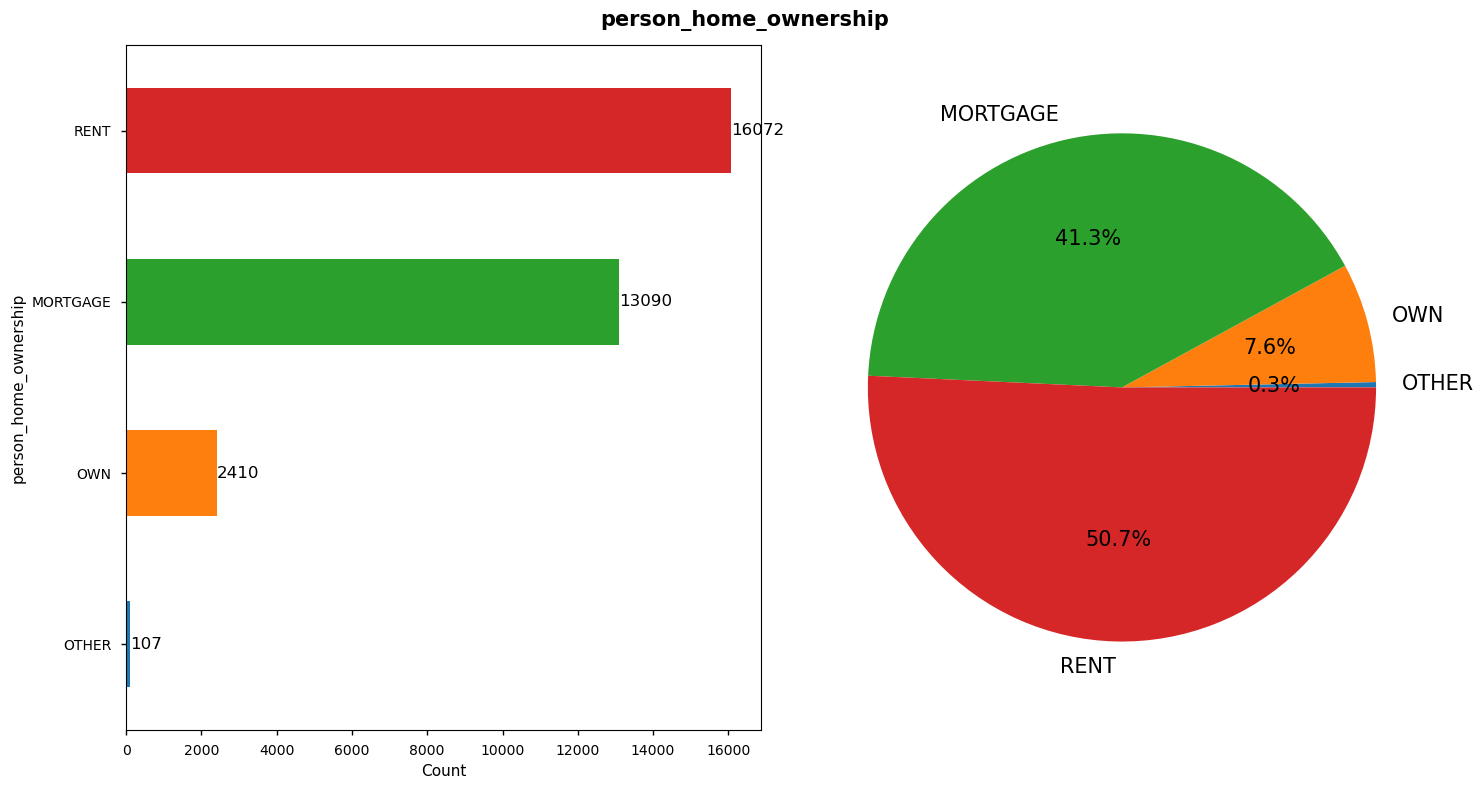

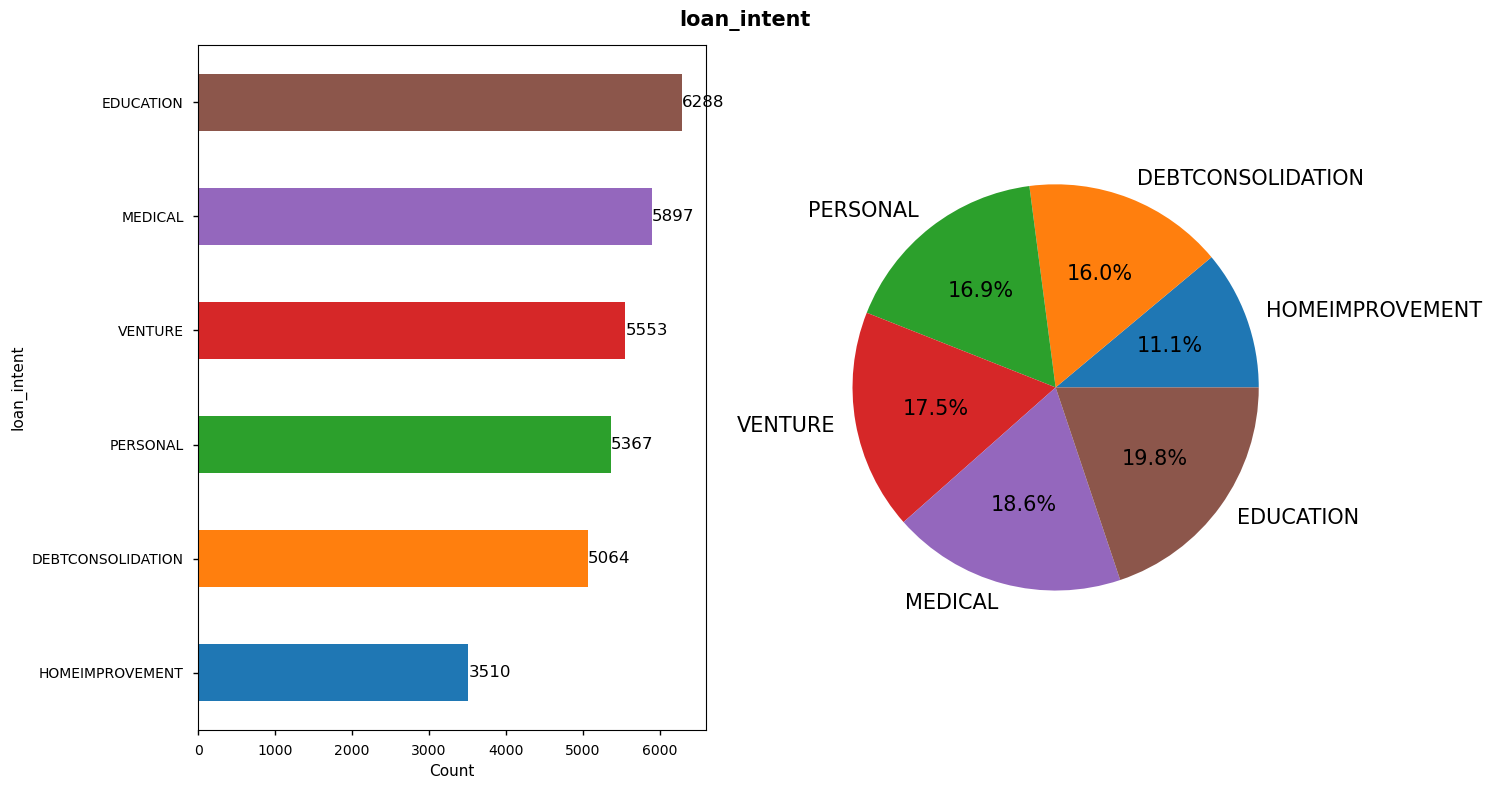

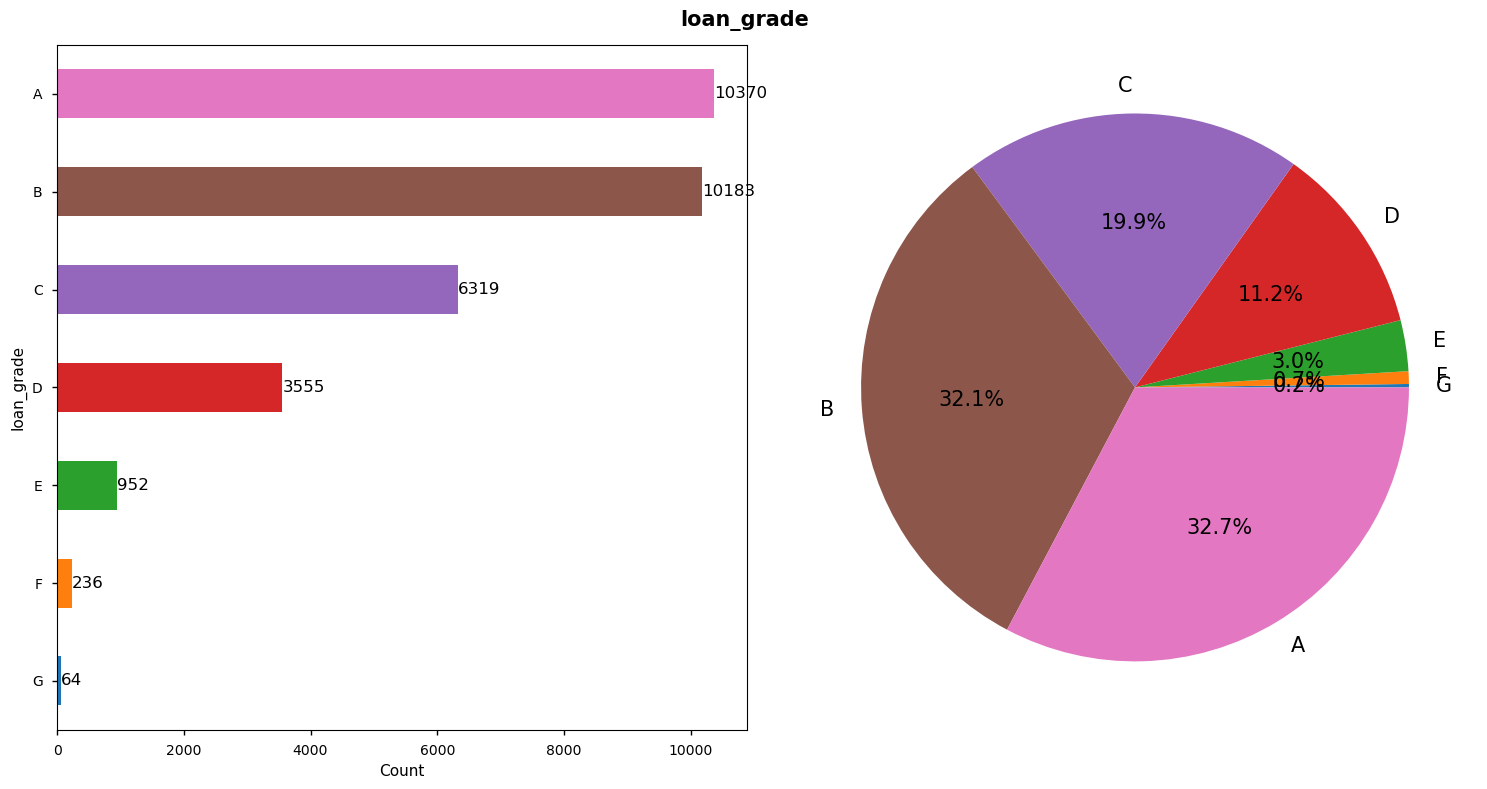

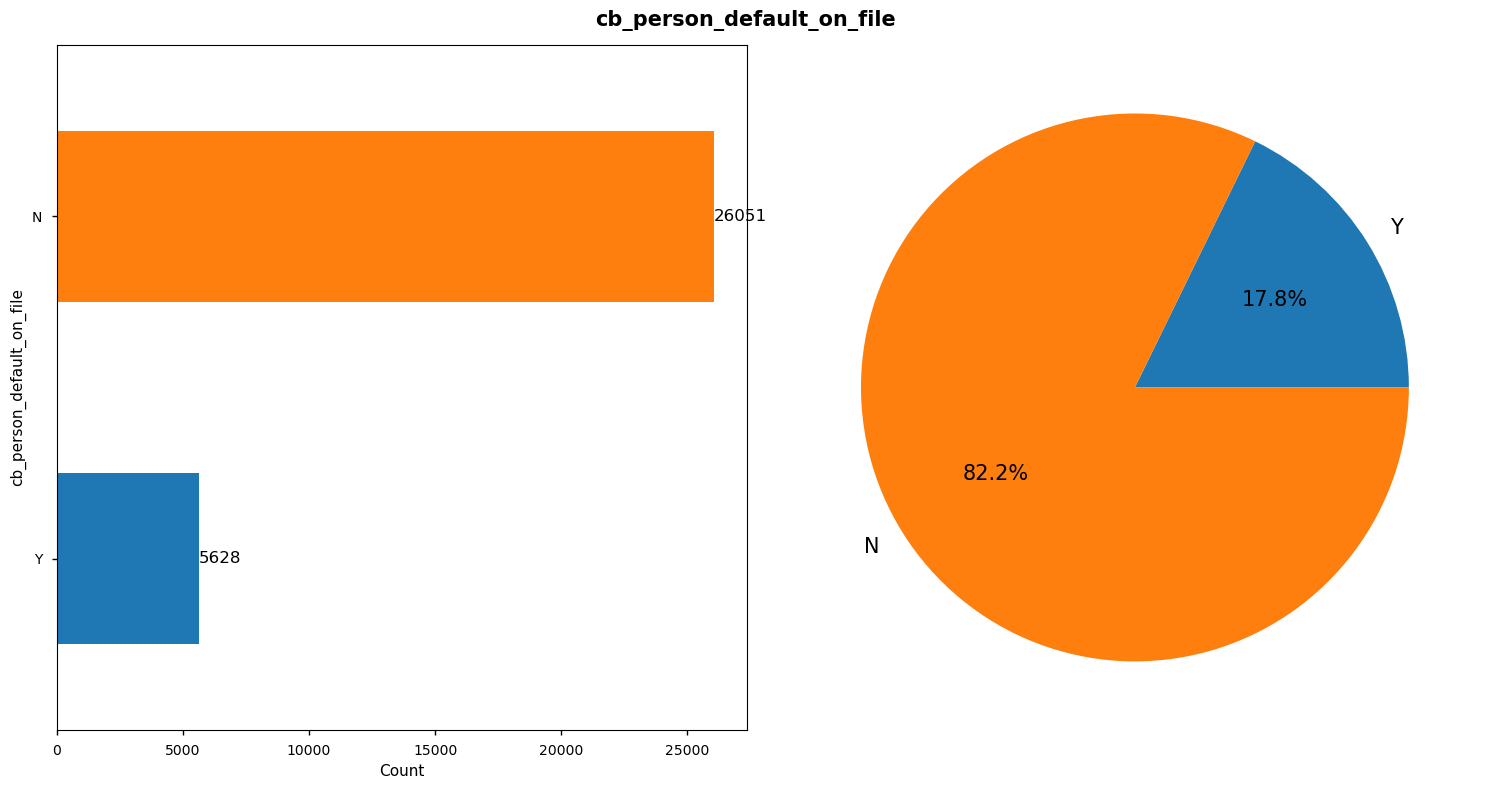

In [14]:
#charts for distribution of categorical variables 
for col in df2.columns:
    if df2[col].dtype == 'O':
        print('\n')
        fig,ax = plt.subplots(1,2,figsize = (15,8))
        fig.suptitle(col,fontsize = 15,weight = 'bold')
        plt.subplot(1,2,1)
        category_count = df2[col].value_counts().sort_values()
        category_count.plot(kind = 'barh',color= plt.cm.tab10.colors)
        for index,value in enumerate(category_count):
            plt.text(value,index,str(value),fontsize = 12,va = 'center')
        plt.xlabel('Count')
        plt.subplot(1,2,2)
        category_count.plot(kind = 'pie',
               labels = category_count.index,
               autopct = '%1.1f%%',
               textprops = {'fontsize':15})
        plt.ylabel('')
        plt.tight_layout()
        plt.show()

### Purpose of creating models is to see if a person who takes out a loan will go into default or not

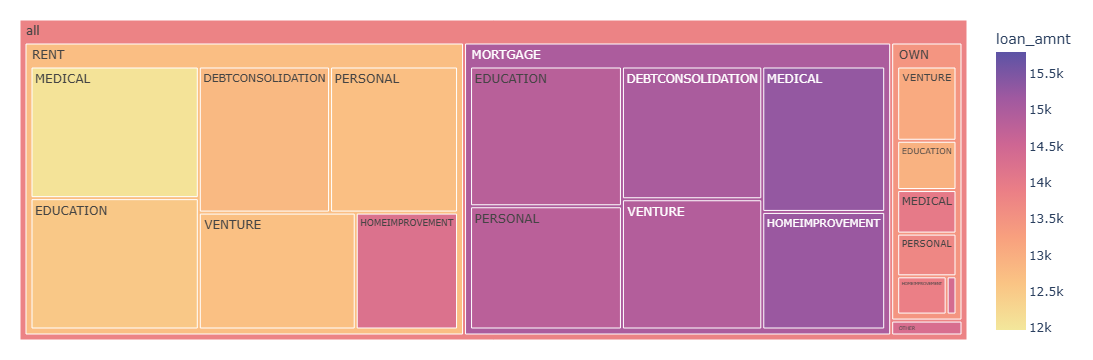

In [15]:
#Treemap to show relationship between loan_amnt, person_home_ownership, and loan_intent

fig = px.treemap(df2, path=[px.Constant("all"), 'person_home_ownership', 'loan_intent'], values='loan_amnt',
                  color='loan_amnt',
                  color_continuous_scale='sunset')
fig.update_layout(margin = dict(t=20, l=20, r=20, b=20))
fig.show()

The treemap shows the majority of renters have the highest loans for Medical and Education. People with mortgages for Education and Personal. 
Home owners have the smallest amount loans taken out with a majority of loan amounts going to Venture and Education. 
Those belonging to the Other category take loans for Venture and Personal. 

In [16]:
#bin ages
bins = [0,18,25,35,45,65,75,np.inf]
names = ['<18', '18-25', '25-35', '35-45','45-65', '65-75','75+']
df2['age_range'] = pd.cut(df2['person_age'], bins, labels=names)

#bin income
bins_inc = [0,4000,10000,30000,50000,70000,90000,100000,np.inf]
names_inc = ['<5K', '5K-10K', '10K-30K', '30K-50K','50K-70K', '70K-90K','90K-100K','100K+']
df2['income_range'] = pd.cut(df2['person_income'], bins_inc, labels=names_inc)

In [17]:
#encode categorical variables for prediction models
model_df = df2.copy()

cat = [
    'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'person_home_ownership', 'age_range',
    'income_range'
]

for col in cat:
    model_df[col] = model_df[col].astype('category').cat.codes
    
model_df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_range,income_range
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2,1,1
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3,1,1
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2,1,4
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4,1,4
5,21,9900,2,2.0,5,0,2500,7.14,1,0.25,0,2,1,1


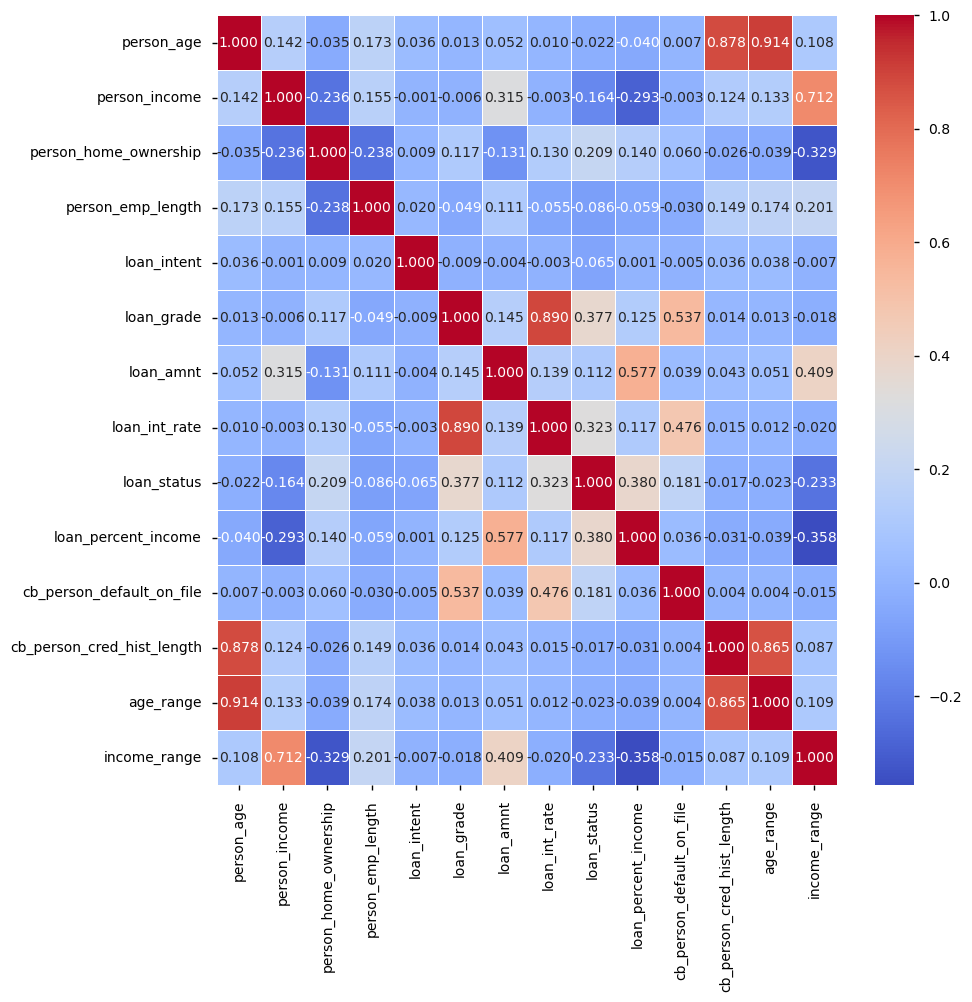

In [18]:
correlation_matrix = model_df.corr()

#correlation heatmap
plt.figure(figsize = (10,10))
sns.heatmap(correlation_matrix,annot = True,cmap = 'coolwarm',fmt = '.3f',linewidths = 0.5)
plt.show()

Correlation heatmap shows there is little correlation between the variables. The highest positive correlated variables 
are ones that used other variables to make the data like age range/age and income range/person income. 
There is quite a bit of possitive correlation it's just small so it's hard to gage how influential the independent variables will have on the 
target variable loan_status. 

In [19]:
#feature selection 
'''list all features'''
features = []
for i in model_df:
    if i != 'loan_status':
        features.append(i)
print(features)

['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'age_range', 'income_range']


#### Model creation

In [20]:
X = model_df[features]
y = model_df['loan_status']

print(X.shape)
print(y.shape)
print(X.shape)
print(y.shape)

(31679, 13)
(31679,)
(31679, 13)
(31679,)


In [21]:
#using f_regression score we can slect k best features
from sklearn.feature_selection import SelectKBest as skb
from sklearn.feature_selection import f_regression

#first we analyze all scores

fs = skb(f_regression,k='all')
fs.fit(X,y)
for i in range(len(fs.scores_)):
    print('Feature %d: %f' %(i,fs.scores_[i]))

Feature 0: 15.521203
Feature 1: 876.943076
Feature 2: 1444.002683
Feature 3: 235.839801
Feature 4: 136.464609
Feature 5: 5247.593667
Feature 6: 403.771445
Feature 7: 3698.852242
Feature 8: 5340.331243
Feature 9: 1074.019769
Feature 10: 8.975138
Feature 11: 17.230575
Feature 12: 1826.674258


In [22]:
#select 8 best features out of 13 and get their names

fs = skb(f_regression, k = 8)
Xnew = fs.fit_transform(X,y)
f = np.array(features)
filt = fs.get_support()
f = f[filt]
print(f,len(f))

['person_income' 'person_home_ownership' 'loan_grade' 'loan_amnt'
 'loan_int_rate' 'loan_percent_income' 'cb_person_default_on_file'
 'income_range'] 8


In [23]:
#drop income_range and age_range then re-run for best features
model_df2 = model_df.drop(['age_range', 'income_range'], axis=1)

features = []
for i in model_df2:
    if i != 'loan_status':
        features.append(i)
print(features)

X = model_df2[features]
y = model_df2['loan_status']

print(X.shape)
print(y.shape)
print(X.shape)
print(y.shape)

#first we analyze all scores

fs = skb(f_regression,k='all')
fs.fit(X,y)
for i in range(len(fs.scores_)):
    print('Feature %d: %f' %(i,fs.scores_[i]))

#now we select 8 best features out of 13 and get their names

fs = skb(f_regression, k = 8)
Xnew = fs.fit_transform(X,y)
f = np.array(features)
filt = fs.get_support()
f = f[filt]
print(f,len(f))

['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']
(31679, 11)
(31679,)
(31679, 11)
(31679,)
Feature 0: 15.521203
Feature 1: 876.943076
Feature 2: 1444.002683
Feature 3: 235.839801
Feature 4: 136.464609
Feature 5: 5247.593667
Feature 6: 403.771445
Feature 7: 3698.852242
Feature 8: 5340.331243
Feature 9: 1074.019769
Feature 10: 8.975138
['person_income' 'person_home_ownership' 'person_emp_length' 'loan_grade'
 'loan_amnt' 'loan_int_rate' 'loan_percent_income'
 'cb_person_default_on_file'] 8


In [24]:
#reshape X
Xnew = X
y = y.values.reshape(-1,1)
print(Xnew.shape)
print(y.shape)

(31679, 11)
(31679, 1)


In [25]:
#splitting the dataset into training and testing

X_train, X_test, y_train, y_test = tts(Xnew, y, test_size = 0.2, random_state = 40)

print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(25343, 11) (25343, 1)
(6336, 11) (6336, 1)


In [26]:
#Linear regression

mlr = LinearRegression()

mlr.fit(X_train, y_train)

print("Intercept: ",mlr.intercept_)
print("Coeffs: ", list(zip(X, mlr.coef_)))

#make predictions
y_pred_mlr = mlr.predict(X_test)

#metrics

MABE = metrics.mean_absolute_error(y_test, y_pred_mlr)
r2 = mlr.score(X_test,y_test)*100

print("R squared score: ",r2)
print("Mean absolute error: ",MABE)

Intercept:  [-0.07302299]
Coeffs:  [('person_age', array([ 5.49718997e-04,  4.67808259e-07,  2.56204284e-02, -1.34935015e-03,
       -1.51916847e-02,  1.44177116e-01, -1.39669660e-05, -8.82063334e-03,
        1.81037056e+00, -2.40641698e-02, -4.39741863e-04]))]
R squared score:  28.70984114289914
Mean absolute error:  0.2616864530485122


Mean absolute error (MAE) helps check how closely predictions match the actual data. A low MAE shows that the predictions are close to the actual values. The Linear Regression model does a good job at predicting.

In [30]:
#Train random forrest model 

y_flattened = y.ravel()
X_train, X_test, y_train_rf, y_test_rf = tts(Xnew, y_flattened, test_size = 0.2, random_state = 40)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train_rf)

# Predict on the test set and calculate the R-squared score
y_pred_rf = rf.predict(X_test)
score = r2_score(y_test_rf, y_pred_rf)

print(f"R2 Score of the model: {score:.3f}")

MABE_rf = metrics.mean_absolute_error(y_test_rf, y_pred_rf)
print("Mean absolute error: ",MABE_rf)

R2 Score of the model: 0.665
Mean absolute error:  0.12033617424242424


The low R-squared and MAE show that the Random Forest model does a good job a predicting if a person will default or not.

In [32]:
#Train Logistic Regression model 

log_reg = LogisticRegression(random_state=30, max_iter=200)

log_reg.fit(X_train, y_train)

print("Intercept: ",log_reg.intercept_)
print("Coeffs: ", list(zip(X, log_reg.coef_)))

y_pred_log_reg = log_reg.predict(X_test)

MABE = metrics.mean_absolute_error(y_test, y_pred_mlr)
r2 = log_reg.score(X_test,y_test)*100

print("Mean absolute error: ",MABE)
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg) * 100)

Intercept:  [-0.08382862]
Coeffs:  [('person_age', array([-7.59844298e-02, -3.31557562e-05,  3.30962557e-01, -2.03516671e-02,
       -2.23397502e-01,  5.80180546e-01,  1.09781250e-04,  2.24866014e-02,
        3.01650187e-02,  6.92874954e-02,  9.24985865e-02]))]
Mean absolute error:  0.2616864530485122
Accuracy: 83.27020202020202


The Logisitic Regression model does a good job at predicting with 83.2% accuracy and a low MAE score. 

In [34]:
# Train Decision Tree

#Train model using gini and entropy
def train_using_gini(X_train, y_train):
    clf_gini = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=5, min_samples_leaf=5)
    clf_gini.fit(X_train, y_train)
    return clf_gini

def train_using_entropy(X_train, y_train):
    clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=5, min_samples_leaf=5)
    clf_entropy.fit(X_train, y_train)
    return clf_entropy

#Create predictions 
def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)
    print("Predicted Values:\n", y_pred)
    return y_pred

#Evaluate the model 
def cal_accuracy(y_test, y_pred):
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nAccuracy:", accuracy_score(y_test, y_pred) * 100)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

if __name__ == "__main__":

  
    print("\n----- Training Using Gini -----")
    clf_gini = train_using_gini(X_train, y_train)
    y_pred_gini = prediction(X_test, clf_gini)
    cal_accuracy(y_test, y_pred_gini)

    
    print("\n----- Training Using Entropy -----")
    clf_entropy = train_using_entropy(X_train, y_train)
    y_pred_entropy = prediction(X_test, clf_entropy)
    cal_accuracy(y_test, y_pred_entropy)


----- Training Using Gini -----
Predicted Values:
 [0 0 1 ... 0 0 0]

Confusion Matrix:
 [[4962   13]
 [ 571  790]]

Accuracy: 90.78282828282829

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.94      4975
           1       0.98      0.58      0.73      1361

    accuracy                           0.91      6336
   macro avg       0.94      0.79      0.84      6336
weighted avg       0.92      0.91      0.90      6336


----- Training Using Entropy -----
Predicted Values:
 [0 0 1 ... 0 0 0]

Confusion Matrix:
 [[4974    1]
 [ 573  788]]

Accuracy: 90.94065656565657

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95      4975
           1       1.00      0.58      0.73      1361

    accuracy                           0.91      6336
   macro avg       0.95      0.79      0.84      6336
weighted avg       0.92      0.91      0.90      6336



We can see that the Gini and Entropy models for a decision tree are very accurate at 90.7% and 90.9% respectively. The decision tree is the best model for the data.

The next steps would be to introduce the models to new data and see how well they do. 